# 06 — Evaluation, calibration, thresholding, and group diagnostics

This notebook consolidated the model predictions, selected the best model by PR-AUC, and examined calibration, lift, threshold-cost behavior, and group-level error differences.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from project_package.config import ensure_project_dirs, PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR, TARGET
from project_package.plotting import save_figure
from project_package.reporting import save_table

ensure_project_dirs()
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

from project_package.evaluation import classification_metrics, metrics_frame, threshold_cost_curve, lift_table, group_error_summary
from project_package.plotting import plot_calibration, plot_confusion
from project_package.models import load_model, save_model

In [2]:
test_df = pd.read_csv(PROCESSED_DIR / "test_split.csv")
standard_preds = pd.read_csv(PROCESSED_DIR / "test_predictions_standard_models.csv")
mlp_preds = pd.read_csv(PROCESSED_DIR / "test_predictions_mlp.csv")

preds = standard_preds.copy()
preds["proba_mlp"] = mlp_preds["proba_mlp"]
y_true = preds["y_true"].values
preds.head()

,y_true,proba_logistic_regression,proba_random_forest,proba_xgboost,proba_mlp
0,0,0.399202,0.290321,0.394513,0.388120
1,0,0.429828,0.331705,0.352582,0.327423
2,0,0.379067,0.382102,0.419038,0.384105
3,1,0.264454,0.328488,0.397142,0.313094
4,0,0.171647,0.125493,0.119272,0.195294


## Consolidated model comparison

The final comparison used the exact same test split for all models.

In [3]:
all_results = {}
for col in [c for c in preds.columns if c.startswith("proba_")]:
    model_name = col.replace("proba_", "")
    all_results[model_name] = classification_metrics(y_true, preds[col].values, threshold=0.5)
final_comparison = metrics_frame(all_results)
save_table(final_comparison, "06_final_model_comparison.csv")
final_comparison

,model,roc_auc,pr_auc,brier_score,log_loss,f1,precision,recall,balanced_accuracy,threshold
0,xgboost,0.781539,0.563667,0.179362,0.542408,0.535478,0.460412,0.639789,0.713432,0.5
1,random_forest,0.780983,0.559121,0.170180,0.520879,0.546571,0.499377,0.603617,0.715889,0.5
2,mlp,0.777646,0.557789,0.185636,0.557260,0.529539,0.449108,0.645064,0.710184,0.5
3,logistic_regression,0.760394,0.522432,0.188838,0.570214,0.510114,0.439303,0.608139,0.693862,0.5


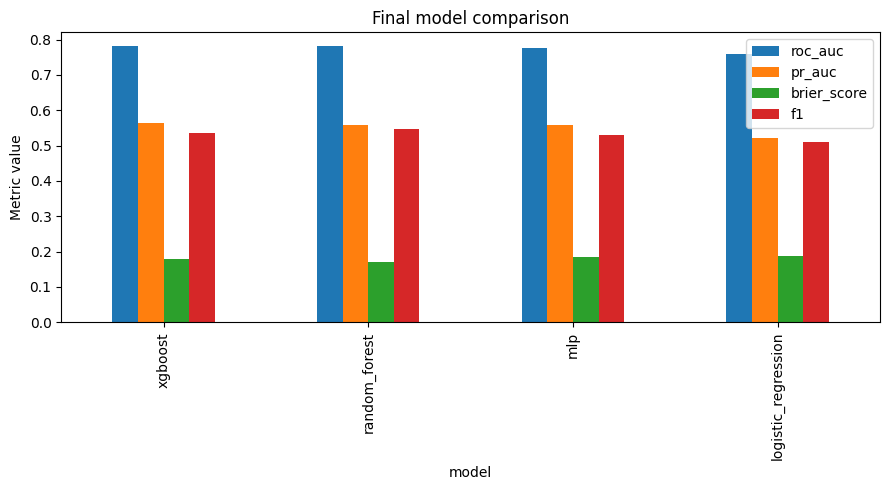

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
final_comparison.set_index("model")[["roc_auc", "pr_auc", "brier_score", "f1"]].plot(kind="bar", ax=ax)
ax.set_title("Final model comparison")
ax.set_ylabel("Metric value")
save_figure(fig, "06_final_model_comparison.png")
plt.show()

## Calibration of the best model

The best model by PR-AUC was carried forward for probability diagnostics and threshold analysis.

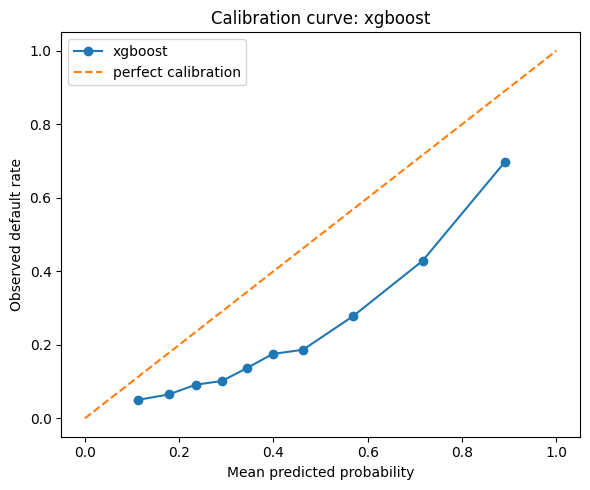

In [5]:
best_model_name = final_comparison.iloc[0]["model"]
best_col = f"proba_{best_model_name}"
best_proba = preds[best_col].values

fig = plot_calibration(y_true, best_proba, best_model_name)
save_figure(fig, f"06_calibration_curve_{best_model_name}.png")
plt.show()

## Threshold-cost analysis

False approvals were assigned a higher cost than false rejections. This reflected the lender's exposure when a high-risk borrower was incorrectly approved. The values were illustrative and should be adjusted with real portfolio economics.

In [6]:
cost_curve = threshold_cost_curve(y_true, best_proba, false_approval_cost=5.0, false_rejection_cost=1.0)
save_table(cost_curve, f"06_threshold_cost_curve_{best_model_name}.csv")
optimal_row = cost_curve.loc[cost_curve["total_cost"].idxmin()].to_dict()
optimal_threshold = float(optimal_row["threshold"])
optimal_row

{'threshold': 0.37,
 'false_approvals': 267.0,
 'false_rejections': 1952.0,
 'total_cost': 3287.0,
 'cost_per_applicant': 0.5478333333333333}

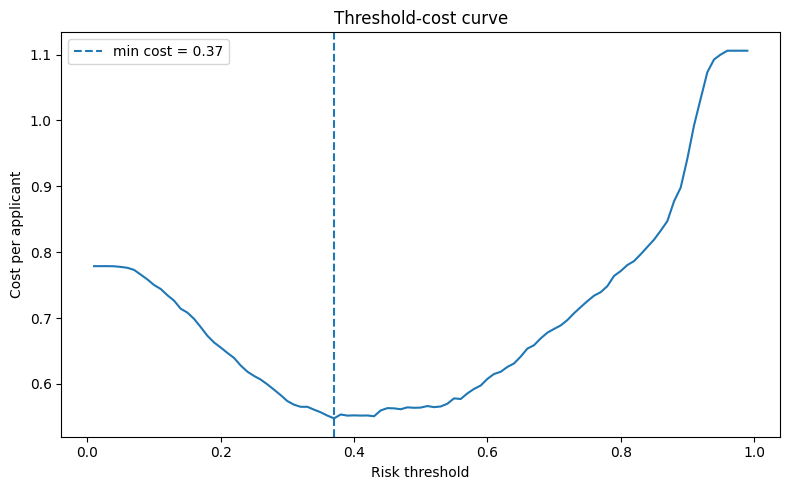

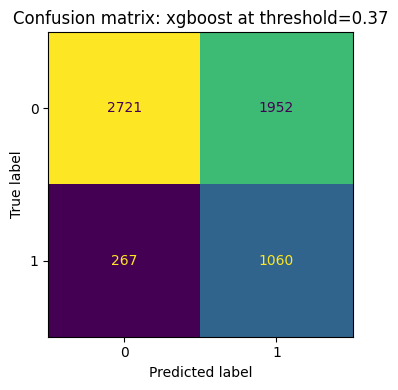

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cost_curve["threshold"], cost_curve["cost_per_applicant"])
ax.axvline(optimal_threshold, linestyle="--", label=f"min cost = {optimal_threshold:.2f}")
ax.set_title("Threshold-cost curve")
ax.set_xlabel("Risk threshold")
ax.set_ylabel("Cost per applicant")
ax.legend()
save_figure(fig, f"06_threshold_cost_curve_{best_model_name}.png")
plt.show()

fig_cm = plot_confusion(y_true, best_proba, threshold=optimal_threshold, model_name=best_model_name)
save_figure(fig_cm, f"06_confusion_matrix_optimal_threshold_{best_model_name}.png")
plt.show()

## Lift table

The lift table assessed whether the model concentrated defaults in the highest-risk deciles.

In [8]:
lift = lift_table(y_true, best_proba, n_bins=10)
save_table(lift, f"06_lift_table_{best_model_name}.csv")
lift

,risk_decile,applicants,default_rate,mean_score,lift
0,1,600,0.698333,0.891351,3.157498
1,2,600,0.428333,0.716061,1.936699
2,3,600,0.278333,0.569147,1.258478
3,4,600,0.186667,0.462789,0.844009
4,5,600,0.175000,0.398140,0.791258
5,6,600,0.136667,0.343498,0.617935
6,7,600,0.101667,0.291099,0.459683
7,8,600,0.091667,0.235725,0.414469
8,9,600,0.065000,0.177809,0.293896
9,10,600,0.050000,0.111846,0.226074


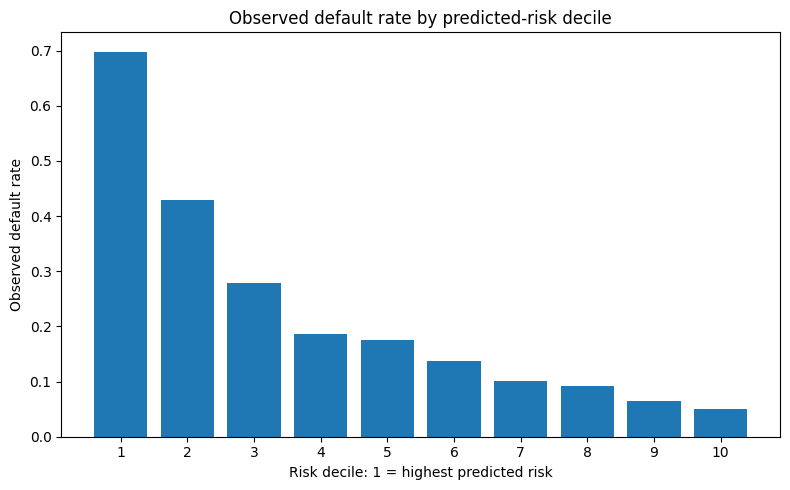

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(lift["risk_decile"].astype(str), lift["default_rate"])
ax.set_title("Observed default rate by predicted-risk decile")
ax.set_xlabel("Risk decile: 1 = highest predicted risk")
ax.set_ylabel("Observed default rate")
save_figure(fig, f"06_default_rate_by_risk_decile_{best_model_name}.png")
plt.show()

## Group-level error diagnostics

These diagnostics were limited by the available public variables. They were included to demonstrate the governance workflow, not to certify fairness.

In [10]:
group_frames = []
for group_col in ["sex", "education", "marriage"]:
    frame = group_error_summary(test_df, y_true, best_proba, group_col=group_col, threshold=optimal_threshold)
    frame["group_variable"] = group_col
    group_frames.append(frame)
group_diagnostics = pd.concat(group_frames, ignore_index=True)
save_table(group_diagnostics, f"06_group_error_diagnostics_{best_model_name}.csv")
group_diagnostics

,group,n,default_rate,mean_score,false_positive_rate,false_negative_rate,approval_rate_at_threshold,group_variable
0,female,3598,0.212896,0.407787,0.393715,0.215405,0.523068,sex
1,male,2402,0.233555,0.437661,0.454644,0.181818,0.460450,sex
2,graduate_school,2130,0.190141,0.377336,0.343188,0.232099,0.576056,education
3,high_school,1014,0.257396,0.456763,0.494024,0.210728,0.429980,education
4,other,82,0.060976,0.201909,0.064935,0.400000,0.902439,education
5,university,2774,0.236482,0.445220,0.464117,0.176829,0.450973,education
6,married,2767,0.241417,0.429795,0.427346,0.194611,0.481388,marriage
7,other,75,0.160000,0.442414,0.523810,0.250000,0.440000,marriage
8,single,3158,0.204877,0.410404,0.407009,0.207110,0.513933,marriage


## Saving best model metadata

The selected model name and operating threshold were saved for Notebook 07 and the Streamlit app.

In [11]:
metadata = pd.DataFrame([{
    "best_model_name": best_model_name,
    "best_probability_column": best_col,
    "selection_metric": "pr_auc",
    "optimal_threshold_by_cost": optimal_threshold,
}])
save_table(metadata, "06_best_model_metadata.csv")

# Copying the best scikit-learn pipeline into a common artifact name when available.
if best_model_name != "mlp":
    model = load_model(f"{best_model_name}_pipeline.joblib")
    save_model(model, "best_credit_scoring_pipeline.joblib")
else:
    print("The MLP was selected. The Streamlit scaffold expected a scikit-learn pipeline; consider using the best non-MLP model for the app.")
metadata

,best_model_name,best_probability_column,selection_metric,optimal_threshold_by_cost
0,xgboost,proba_xgboost,pr_auc,0.37
